
# <center>**Optimization & Machine Learning M**</center>
Project - June 8th 2026

Louise CABROLIER


***Introduction:***

As part of the management of its transport infrastructure in Washington D.C., the Capital Bikeshare company faces a major logistical challenge: the asymmetry of traffic flows throughout the day. This phenomenon creates critical situations where some stations (docks) become completely empty, preventing bicycle rentals, while others are saturated, blocking bike drop-offs.

Since each journey generates precise data (times, weather, stations), this project proposes to jointly leverage data science, machine learning and operations research to anticipate demand and optimize the redistribution logistics of the network.

***Machine Learning Tasks***

1. Data Exploration and Preprocessing

In [2]:
#Import of the library:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Document recovery
url_csv = "https://raw.githubusercontent.com/louisecabrolier/bike-project/refs/heads/main/bike_sharing_dataset.csv"
url_json = "https://raw.githubusercontent.com/louisecabrolier/bike-project/refs/heads/main/or_data.json"

In [4]:
#Exploration
df = pd.read_csv(url_csv) #loads the CSV file  into a dataframe
print(df.shape) #displays the table dimensions
print(df.head()) #displays the first 5 rows of the table

(17379, 20)
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum pctghum  windspeed  comfindex  casual  \
0           1  0.24  0.2879  0.81     81%        0.0      0.168       3   
1           1  0.22  0.2727  0.80     80%        0.0      0.154       8   
2           1  0.22  0.2727  0.80     80%        0.0      0.154       5   
3           1  0.24  0.2879  0.75     75%        0.0      0.168       3   
4           1  0.24  0.2879  0.75     75%        0.0      0.168       0   

   registered  cnt  simurevenue  
0          13   16         31.5  


In [5]:
#Missing values
print(df.isnull().sum()) #Count the number of missing values in each of the columns

instant          0
dteday           0
season           0
yr               0
mnth             0
hr               0
holiday          0
weekday          0
workingday       0
weathersit       0
temp           132
atemp            0
hum            192
pctghum        192
windspeed        0
comfindex      132
casual           0
registered       0
cnt              0
simurevenue      0
dtype: int64


In [6]:
#Replace the missing values in each column with the median
df['temp'] = df['temp'].fillna(df['temp'].median())
df['hum'] = df['hum'].fillna(df['hum'].median())

df['pctghum'] = df['pctghum'].str.replace('%', '', regex=False).astype(float) / 100

df['pctghum'] = df['pctghum'].fillna(df['pctghum'].median())
df['comfindex'] = df['comfindex'].fillna(df['comfindex'].median())
print(df.isnull().sum())

instant        0
dteday         0
season         0
yr             0
mnth           0
hr             0
holiday        0
weekday        0
workingday     0
weathersit     0
temp           0
atemp          0
hum            0
pctghum        0
windspeed      0
comfindex      0
casual         0
registered     0
cnt            0
simurevenue    0
dtype: int64


In [7]:
print(df.describe()) #displays basic statistics for each column

          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.497047   
std        0.167165      2.005771      0.465431      0.639357      0.

In [8]:
#Anomalies

#Corrects impossible negative values
df['windspeed'] = df['windspeed'].where(df['windspeed'] >= 0, df['windspeed'].median())

#Inspects the lines to detect any outliers with cnt > 800
print(df[df['cnt'] > 800].shape)
print(df[df['cnt'] > 800][['hr', 'temp', 'hum', 'windspeed', 'cnt']].describe())

(152, 20)
               hr        temp         hum   windspeed          cnt
count  152.000000  152.000000  152.000000  152.000000   152.000000
mean    16.394737    0.678553    0.509605    0.206504  1106.756579
std      3.367468    0.109837    0.153269    0.103855  1368.695159
min      3.000000    0.300000    0.240000    0.000000   801.000000
25%     17.000000    0.620000    0.387500    0.164200   821.500000
50%     17.000000    0.700000    0.490000    0.223900   846.500000
75%     18.000000    0.760000    0.620000    0.261175   886.000000
max     18.000000    0.860000    0.890000    0.492500  8500.000000


In [9]:
#Displays the lines to identify outliers but with cnt > 1000
print(df[df['cnt'] > 1000][['dteday', 'hr', 'temp', 'hum', 'cnt', 'casual', 'registered']])

           dteday  hr  temp   hum   cnt  casual  registered
2453   2011-04-17   3  0.40  0.66  8500     500        8000
3989   2011-06-20   3  0.64  0.89  8500     500        8000
6493   2011-10-03   3  0.36  0.81  8500     500        8000
8648   2012-01-01   3  0.30  0.81  8500     500        8000
14638  2012-09-07   3  0.62  0.83  8500     500        8000


In [10]:
df = df[df['cnt'] <= 1000] #removes the 5 outliers keeping only the lines with cnt <= 1000
print(df.shape) #checks the new number of lines

(17374, 20)


In [11]:
#Removes unnecessary or problematic colums and saves the result
columns_td = ['instant', 'dteday', 'casual', 'registered', 'pctghum', 'simurevenue', 'atemp', 'comfindex']
df_after_cleaning = df.drop(columns=columns_td)
print(df_after_cleaning.shape) #checks the dimensions
print(df_after_cleaning.columns.tolist()) #displays the list of remaining columns

(17374, 12)
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']


In [12]:
#Encodes the cyclic variables
df_after_cleaning['hr_sin'] = np.sin(2 * np.pi * df_after_cleaning['hr'] / 24)
df_after_cleaning['hr_cos'] = np.cos(2 * np.pi * df_after_cleaning['hr'] / 24)
df_after_cleaning['mnth_sin'] = np.sin(2 * np.pi * df_after_cleaning['mnth'] / 12)
df_after_cleaning['mnth_cos'] = np.cos(2 * np.pi * df_after_cleaning['mnth'] / 12)
df_after_cleaning['weekday_sin'] = np.sin(2 * np.pi * df_after_cleaning['weekday'] / 7)
df_after_cleaning['weekday_cos'] = np.cos(2 * np.pi * df_after_cleaning['weekday'] / 7)

df_ac2 = df_after_cleaning.drop(columns=['hr', 'mnth', 'weekday']) #removes the original cyclic columns

df_ac3 = pd.get_dummies(df_ac2, columns=['season', 'weathersit']) #applies one-hot encoding to categorical variables

#Checks the dimensions and column list of the final Dataframe
print(df_ac3.shape)
print(df_ac3.columns.tolist())

(17374, 21)
['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'cnt', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'season_1', 'season_2', 'season_3', 'season_4', 'weathersit_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']


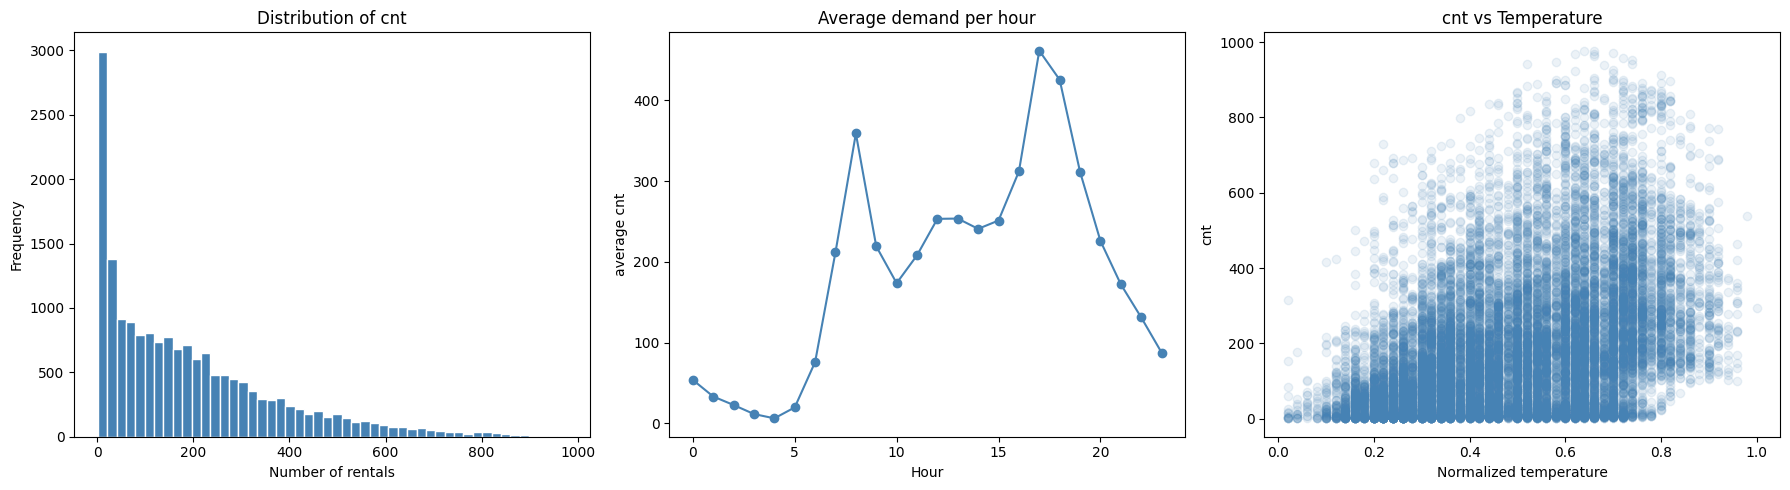

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #creates a figure with 3 graphs

#Plots the histogram of thr cnt distribution
axes[0].hist(df_ac3['cnt'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of cnt')
axes[0].set_xlabel('Number of rentals')
axes[0].set_ylabel('Frequency')

#Reconstructs the time from sin/cos
hr_approx = np.round(np.arctan2(df_ac3['hr_sin'], df_ac3['hr_cos']) * 24 / (2 * np.pi)).astype(int) % 24
#Calculates the average demand per hour
cnt_hr = df_ac3.groupby(hr_approx)['cnt'].mean()
#Plots the curve
axes[1].plot(cnt_hr.index, cnt_hr.values, marker='o', color='steelblue')
axes[1].set_title('Average demand per hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('average cnt')

#Draws a scatter plot
axes[2].scatter(df_ac3['temp'], df_ac3['cnt'], alpha=0.1, color='steelblue')
axes[2].set_title('cnt vs Temperature')
axes[2].set_xlabel('Normalized temperature')
axes[2].set_ylabel('cnt')

plt.tight_layout() #adjusts the spacing between the 3 graphs
plt.show() #displays the figure


## Analysis

**Distribution of cnt:** The distribution is strongly right-skewed. The majority of hours record fewer than 200 rentals, with a long tail toward higher values.

**Demand by hour:** Two clear peaks are observed, corresponding to commuting hours: a morning peak around 8am and a larger evening peak around 5-6pm. Demand is almost zero between 2am and 5am.

**cnt vs Temperature:** Demand tends to increase with temperature up to around 0.6-0.7 (approximately 25-30°C), then stabilizes. Very low temperatures (< 0.2) are associated with weak demand. The relationship is positive but non-linear.

2. Model Development and Evaluation

In [14]:
#Data Splitting

from sklearn.model_selection import train_test_split

x = df_ac3.drop(columns=['cnt']) #separates features (x) from the target variable (y)
y = df_ac3['cnt']

#Splits the data into 80% training and 20% testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train : {x_train.shape}")
print(f"Test  : {x_test.shape}")

Train : (13899, 20)
Test  : (3475, 20)


In [15]:
#Baseline Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Trains a baseline Linear Regression model on the training data
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test) #generates predictions on the test set

#Evaluates the model's performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr)) #average error magnitude
mae = mean_absolute_error(y_test, y_pred_lr) #mean absolute error
r2 = r2_score(y_test, y_pred_lr) #proportion of variance explained

#Displays their values
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 126.31
MAE  : 91.62
R²   : 0.5009


In [16]:
#Advanced Modeling

from sklearn.ensemble import RandomForestRegressor

#Trains a Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test) #Generates predictions on the test set

#Evaluates the Random Forest performance
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

RMSE : 41.55
MAE  : 25.65
R²   : 0.9460


In [17]:
#Fine-tuning

from sklearn.model_selection import GridSearchCV

#Defines the hyperparameter search space
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5]
}

#Optimizes the Random Forest hyperparameters by testing all combinations
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best RMSE (CV)   : {-grid_search.best_score_:.2f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE (CV)   : 44.59


3. Prediction and Interpretation

In [18]:
#Evaluation

#Retrieves the best model found by Grid Search and evaluates its final performance on the test set
best_rf = grid_search.best_estimator_

y_pred_final = best_rf.predict(x_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("Model comparison:")
print(f"Linear Regression   -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")
print(f"Random Forest       -> RMSE: {rmse_rf:.2f} | MAE: {mae_rf:.2f} | R²: {r2_rf:.4f}")
print(f"Tuned Random Forest -> RMSE: {rmse_final:.2f} | MAE: {mae_final:.2f} | R²: {r2_final:.4f}")

Model comparison:
Linear Regression   -> RMSE: 126.31 | MAE: 91.62 | R²: 0.5009
Random Forest       -> RMSE: 41.55 | MAE: 25.65 | R²: 0.9460
Tuned Random Forest -> RMSE: 41.36 | MAE: 25.51 | R²: 0.9465


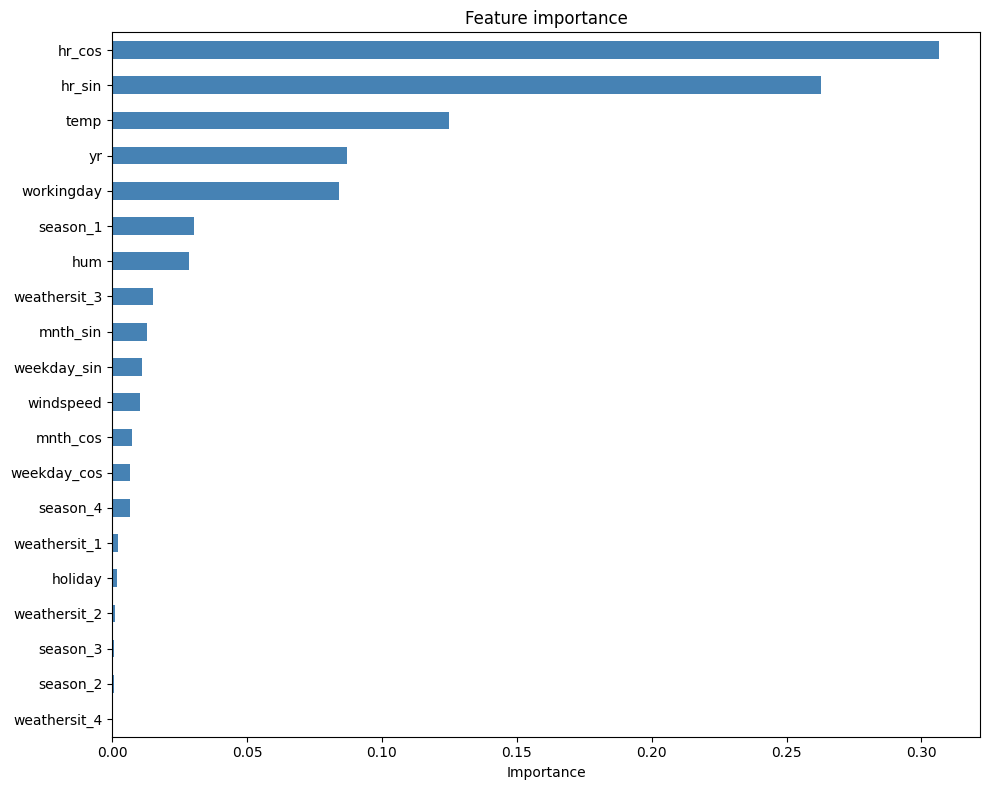

In [19]:
#Feature Importance

#Extracts and visualizes the most important features ranked by their contribution to the model's predictions
feat_importance = pd.Series(best_rf.feature_importances_, index=x.columns)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Feature Importance and Conclusion

The two most important features are `hr_cos` and `hr_sin`, together accounting for about 56% of the model's importance. This makes sense given the two demand peaks we saw earlier around 8am and 5-6pm.

Followed by `temp` with more than 13%, which matches the positive relationship between temperature and demand seen in the exploratory analysis.

Then, `yr`, with approximately 9%, reflects the overall growth in service usage between 2011 and 2012, and finally `workingday` (~8%) shows that commuting trips drive a large part of the demand.

Overall, these results match what we observed during the EDA: hour and temperature were already the variables most correlated with cnt.

Based on this, a few business recommendations:
- Redistribute bikes before the morning (8am) and evening (5pm) peaks.
- Increase station capacity during summer and good weather periods.
- Plan for continued year-over-year demand growth.

***Operations Research Task***

In [20]:
#Mathematical Formulation

**Problem:** We have 20 stations, some with a bike surplus and others with a deficit.
The goal is to redistribute bikes while minimizing the total distance traveled by trucks.

**Variables:**
- SS = set of surplus stations (supply_demand > 0)
- DS = set of deficit stations (supply_demand < 0)
- c_ij = distance in km between station i and station j
- X_ij = number of bikes to move from station i to station j

**Linear Program:**

Minimize: Σ c_ij × X_ij for all i ∈ SS, j ∈ DS

Subject to:
- Σ_j X_ij ≤ supply_i for all i ∈ SS &nbsp;&nbsp;&nbsp; (cannot send more bikes than available surplus)
- Σ_i X_ij ≥ |demand_j| for all j ∈ DS &nbsp;&nbsp; (deficit at each station must be fully satisfied)
- X_ij ≥ 0 for all i, j &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (no negative transport)

In [21]:
#Implementation

import json
import pulp #Utilizing the standard OR wrapper
import urllib.request

#Loads the data from or_data
with urllib.request.urlopen(url_json) as response:
  or_data = json.loads(response.read().decode())
  print("Dataset and or_data loaded successfully")

stations = or_data['stations']
supply_demand = or_data['supply_demand']
distance_matrix = or_data['distance_matrix']

#Splits the 20 stations into two groups
SS = [i for i, v in enumerate(supply_demand) if v > 0]  #surplus indices
DS = [j for j, v in enumerate(supply_demand) if v < 0]  #deficit indices

#Extracts their respective bike counts as positive values
supply = {i: supply_demand[i] for i in SS}
demand = {j: abs(supply_demand[j]) for j in DS}  #convert to positive values

#Displays the result for verification
print("Surplus stations:", [(stations[i], supply[i]) for i in SS])
print("Deficit stations:", [(stations[j], demand[j]) for j in DS])

Dataset and or_data loaded successfully
Surplus stations: [('Station_1', 11), ('Station_2', 8), ('Station_3', 17), ('Station_4', 19), ('Station_5', 15), ('Station_6', 12), ('Station_7', 17), ('Station_8', 9)]
Deficit stations: [('Station_9', 7), ('Station_10', 10), ('Station_11', 3), ('Station_12', 7), ('Station_13', 11), ('Station_14', 11), ('Station_15', 8), ('Station_16', 5), ('Station_17', 4), ('Station_18', 8), ('Station_19', 8), ('Station_20', 3)]


In [22]:
#Creation of the model
or_model = pulp.LpProblem("bike_redistribution", pulp.LpMinimize)

#Decision variables: X[i][j] = number of bikes to move from station i to station j
X = {(i, j): pulp.LpVariable(f"X_{i}_{j}", lowBound=0, cat='Integer')
     for i in SS for j in DS}

#Objective function: minimize the total distance traveled by trucks
or_model += pulp.lpSum(distance_matrix[i][j] * X[i, j] for i in SS for j in DS)

#Surplus constraints: the number of bikes sent from each surplus station cannot exceed its available surplus
for i in SS:
    or_model += pulp.lpSum(X[i, j] for j in DS) <= supply[i]

#Deficit constraints: the number of bikes received by each deficit station must fully cover its shortage
for j in DS:
    or_model += pulp.lpSum(X[i, j] for i in SS) >= demand[j]

#Solve the linear program using the CBC solver
or_model.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Status: {pulp.LpStatus[or_model.status]}")
print(f"Total optimized cost: {pulp.value(or_model.objective):.2f} km")

Status: Optimal
Total optimized cost: 153.40 km


In [23]:
print("Optimal redistribution plan\n")
for i in SS:
    for j in DS:
        val = pulp.value(X[i, j])
        if val > 0:
            print(f"{stations[i]} → {stations[j]} : {int(val)} {'bike' if int(val) == 1 else 'bikes'}  ({distance_matrix[i][j]} km)")

print(f"\n Total cost : {pulp.value(or_model.objective):.2f} km")

Optimal redistribution plan

Station_1 → Station_12 : 7 bikes  (0.5 km)
Station_1 → Station_17 : 4 bikes  (0.6 km)
Station_2 → Station_13 : 2 bikes  (6.1 km)
Station_2 → Station_15 : 6 bikes  (2.7 km)
Station_3 → Station_14 : 11 bikes  (1.5 km)
Station_4 → Station_9 : 3 bikes  (1.1 km)
Station_4 → Station_18 : 8 bikes  (1.5 km)
Station_4 → Station_19 : 8 bikes  (0.1 km)
Station_5 → Station_11 : 1 bike  (2.1 km)
Station_5 → Station_15 : 2 bikes  (2.9 km)
Station_5 → Station_20 : 3 bikes  (1.6 km)
Station_6 → Station_10 : 10 bikes  (1.0 km)
Station_6 → Station_11 : 2 bikes  (0.3 km)
Station_7 → Station_9 : 4 bikes  (1.7 km)
Station_7 → Station_16 : 5 bikes  (2.1 km)
Station_8 → Station_13 : 9 bikes  (5.1 km)

 Total cost : 153.40 km


## Conclusion - Optimization

The solver finds an optimal solution with a total cost of 153.40 km.

The model consistently prioritizes the closest stations
  (e.g. Station_4 → Station_19 at 0.1 km, Station_6 → Station_11 at 0.3 km).

All 85 missing bikes are redistributed using the 108 available in surplus stations.

Only 16 station pairs are used out of the 96 possible (8×12),
  demonstrating the efficiency of the optimization.

**Business recommendation:** Perform these transfers at the beginning of the night
to prepare the network before the morning demand peaks (8am).